# Actividad 1: Modelos no lineales

- Alex Rubiño Fernández
- Aprendizaje Automático 2
- 06/04/2026
- UNIR

## Índice

1. [Ejercicio 1: Generación y visualización del dataset](#ejercicio-1-generación-y-visualización-del-dataset)
2. [Ejercicio 2: SVM con kernel lineal y ajuste de hiperparámetros](#ejercicio-2-svm-con-kernel-lineal-y-ajuste-de-hiperparámetros)
3. [Ejercicio 3: SVM con kernels no lineales y ajuste de hiperparámetros](#ejercicio-3-svm-con-kernels-no-lineales-y-ajuste-de-hiperparámetros)
4. [Ejercicio 4: Visualización de fronteras de decisión y comparativa de rendimiento](#ejercicio-4-visualización-de-fronteras-de-decisión-y-comparativa-de-rendimiento)
5. [Ejercicio 5: Discusión y comparación de resultados](#ejercicio-5-discusión-y-comparación-de-resultados)

## Ejercicio 1: Generación y visualización del dataset

Generamos un dataset sintético con las siguientes características: dos clases que forman dos lunas intercaladas, una tercera clase con distribución gaussiana y solapamiento entre todas las clases. Por último, visualizamos el dataset resultante.

Para ello, usamos make_moons para crear las dos lunas, con 300 muestras y un nivel de ruido de 0.2. Para la tercera clase, empleamos make_blobs generando 200 muestras alrededor del centro (0, 0.5) con una desviación estándar de 0.4. Después combinamos ambos conjuntos y mostramos los datos en un gráfico de dispersión, asignando un color diferente a cada clase. Finalmente, dividimos el dataset en entrenamiento (70%) y prueba (30%), manteniendo la proporción original de las clases.

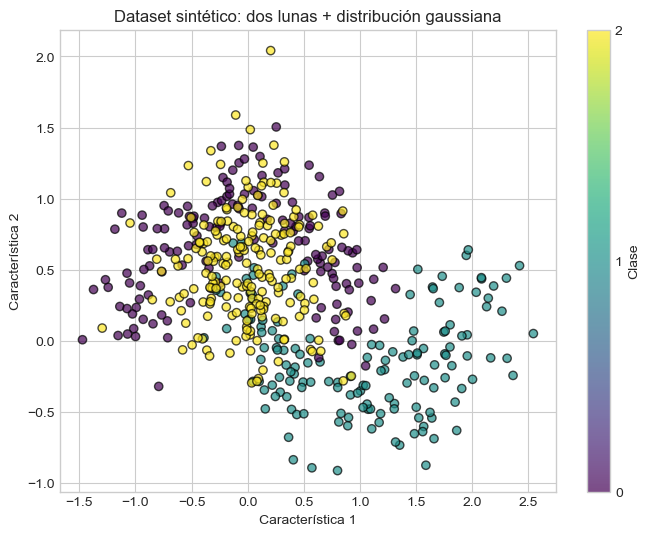

Tamaño del dataset total: 500 muestras
Tamaño entrenamiento: 350, prueba: 150
Distribución de clases en entrenamiento: [105 105 140]
Distribución de clases en prueba: [45 45 60]


In [38]:
# Importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs
from sklearn.model_selection import train_test_split
import seaborn as sns

# Configuración para visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Generamos dos lunas intercaladas (clase 0 y 1)
X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=42)

# Generamos una tercera clase con distribución gaussiana alrededor del centro
X_gauss, y_gauss = make_blobs(n_samples=200, centers=[[0, 0.5]], cluster_std=0.4, random_state=42)
y_gauss = np.full(len(X_gauss), 2)  # Asignar clase 2

# Combinamos los datasets
X = np.vstack([X_moons, X_gauss])
y = np.hstack([y_moons, y_gauss])

# Visualizamos el dataset
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', alpha=0.7)
plt.colorbar(scatter, ticks=[0, 1, 2], label='Clase')
plt.title('Dataset sintético: dos lunas + distribución gaussiana')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

# Dividimos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamaño del dataset total: {X.shape[0]} muestras")
print(f"Tamaño entrenamiento: {X_train.shape[0]}, prueba: {X_test.shape[0]}")
print(f"Distribución de clases en entrenamiento: {np.bincount(y_train)}")
print(f"Distribución de clases en prueba: {np.bincount(y_test)}")

## Ejercicio 2: SVM con kernel lineal y ajuste de hiperparámetros

Implementamos un SVM con kernel lineal sobre el dataset generado. Para ello, realizamos una búsqueda exhaustiva del hiperparámetro C (regularización) mediante GridSearchCV con validación cruzada de 5 folds, evaluando los valores [0.1, 1, 10, 100]. Se selecciona el modelo con mejor accuracy y se evalúa en el conjunto de prueba.

In [39]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Definimos el modelo y parámetros
svm_linear = SVC(kernel='linear')
param_grid_linear = {
    'C': [0.1, 1, 10, 100]
}

# GridSearchCV con validación cruzada
grid_linear = GridSearchCV(svm_linear, param_grid_linear, cv=5, scoring='accuracy', n_jobs=-1)
grid_linear.fit(X_train, y_train)

# Mejor modelo
best_svm_linear = grid_linear.best_estimator_
print(f"Mejor parámetro C: {grid_linear.best_params_['C']}")
print(f"Mejor accuracy en validación cruzada: {grid_linear.best_score_:.4f}")

# Evaluación en test
y_pred_linear = best_svm_linear.predict(X_test)
acc_linear = accuracy_score(y_test, y_pred_linear)
print(f"Accuracy en test: {acc_linear:.4f}")

# Informe de clasificación
print("\nClassification Report (SVM lineal):")
print(classification_report(y_test, y_pred_linear, target_names=['Clase 0 (luna)', 'Clase 1 (luna)', 'Clase 2 (gaussiana)']))

Mejor parámetro C: 0.1
Mejor accuracy en validación cruzada: 0.6114
Accuracy en test: 0.6333

Classification Report (SVM lineal):
                     precision    recall  f1-score   support

     Clase 0 (luna)       0.00      0.00      0.00        45
     Clase 1 (luna)       0.78      0.78      0.78        45
Clase 2 (gaussiana)       0.57      1.00      0.73        60

           accuracy                           0.63       150
          macro avg       0.45      0.59      0.50       150
       weighted avg       0.46      0.63      0.52       150



c:\Users\alexr\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\alexr\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\alexr\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Mediante el SVM, el clasificador ha buscado una línea recta en 2D, un plano en 3D o un hiperplano en más dimensiones para separar las clases lo mejor posible. El kernel lo hemos definido como lineal en SVC(kernel='linear'). El parámetro C controla la regularización: si C es pequeño, el margen es más ancho y permite más errores; si C es grande, el margen es más estrecho e intenta clasificar todo correctamente. En este caso hemos definido los siguientes valores para C: [0.1, 1, 10, 100].

Con GridSearchCV probamos cada valor de C con validación cruzada (cv=5). Averiguamos que el mejor accuracy se obtiene para C = 0.1. A partir de este valor, entrenamos el modelo final con los datos de entrenamiento y, por último, evaluamos el test prediciendo las 150 muestras de prueba y calculando el accuracy.

Observando los resultados, el modelo no predijo ninguna muestra como Clase 0, ya que no acertó ninguna predicción de esta clase (precision = 0.0) y no identificó ninguna de las 45 muestras reales de Clase 0 (recall = 0.0). Esto se debe a que el dataset tiene dos lunas intercaladas (Clase 0 y Clase 1). Una línea recta no puede separarlas. El SVM lineal intenta trazar una línea que separe las tres clases, pero al no poder, "ignora" la Clase 0 y la asigna a otra clase. En la Clase 2 (gaussiana) sí identificó todas las muestras, pero también clasificó erróneamente muchas muestras de otras clases como Clase 2 (precision = 0.57).

Por ello aparece el warning UndefinedMetricWarning, ya que cuando precision o recall no se pueden calcular porque el denominador es cero, scikit-learn lanza esta advertencia. En nuestro caso, como no hay predicciones de Clase 0, TP = 0 y FP = 0, por lo que la precision no se puede calcular.

En conclusión, el SVM lineal no es adecuado para este dataset porque:

- La separación entre las dos lunas es no lineal.
- El modelo no puede trazar una línea recta que las separe.
- Como resultado, la Clase 0 queda "invisible" para el clasificador.

## Ejercicio 3: SVM con kernels no lineales y ajuste de hiperparámetros

Esta vez, repetimos el entrenamiento aplicando kernels no lineales a un nuevo modelo SVM y ajustando también sus hiperparámetros.

In [40]:
# Definimos el modelo y los parámetros para kernels no lineales
svm_nonlinear = SVC()
param_grid_nonlinear = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['rbf', 'poly'],
    'degree': [2, 3]  # solo para kernel poly
}

# GridSearchCV
grid_nonlinear = GridSearchCV(svm_nonlinear, param_grid_nonlinear, cv=5, scoring='accuracy', n_jobs=-1)
grid_nonlinear.fit(X_train, y_train)

# Mejor modelo
best_svm_nonlinear = grid_nonlinear.best_estimator_
print(f"Mejores parámetros: {grid_nonlinear.best_params_}")
print(f"Mejor accuracy en validación cruzada: {grid_nonlinear.best_score_:.4f}")

# Evaluación en test
y_pred_nonlinear = best_svm_nonlinear.predict(X_test)
acc_nonlinear = accuracy_score(y_test, y_pred_nonlinear)
print(f"Accuracy en test: {acc_nonlinear:.4f}")

# Classification Report
print("\nClassification Report (SVM no lineal):")
print(classification_report(y_test, y_pred_nonlinear, target_names=['Clase 0 (luna)', 'Clase 1 (luna)', 'Clase 2 (gaussiana)'], zero_division=0))

Mejores parámetros: {'C': 100, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Mejor accuracy en validación cruzada: 0.7657
Accuracy en test: 0.7600

Classification Report (SVM no lineal):
                     precision    recall  f1-score   support

     Clase 0 (luna)       0.72      0.69      0.70        45
     Clase 1 (luna)       0.97      0.78      0.86        45
Clase 2 (gaussiana)       0.68      0.80      0.73        60

           accuracy                           0.76       150
          macro avg       0.79      0.76      0.77       150
       weighted avg       0.78      0.76      0.76       150



En esta ocasión, vemos una mejora importante en los resultados respecto al ejercicio anterior, ya que al aplicar kernels no lineales como el kernel de base radial (RBF), que es el más común para datos no lineales, y el kernel polinómico (poly), el modelo consigue adaptarse mejor a la forma de los datos.

Los nuevos parámetros introducidos son:

- gamma: controla la influencia de cada muestra. Un gamma alto hace que cada muestra tenga una influencia muy local, mientras que un gamma bajo la extiende más. Los valores probados han sido: 'scale', 'auto', 0.1 y 1.

- degree: grado del polinomio, solo para el kernel poly. Los valores probados han sido 2 y 3.

Con GridSearchCV probamos cada combinación de hiperparámetros con validación cruzada de 5 folds (cv=5). Averiguamos que la mejor combinación es {'C': 100, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}, con un accuracy en validación cruzada del 76.57%. Entrenamos el modelo final con estos parámetros y evaluamos en test, obteniendo un accuracy del 76.00%.

Observando los resultados, el modelo no lineal ha logrado clasificar correctamente las tres clases. La Clase 0 (luna), que antes era completamente ignorada, ahora obtiene una precision de 0.72 y un recall de 0.69, lo que demuestra que el kernel RBF es capaz de trazar una frontera curva que separa las dos lunas. La Clase 1 (luna) obtiene una precision muy alta (0.97), aunque su recall es algo menor (0.78). La Clase 2 (gaussiana) mejora su precision respecto al modelo lineal (de 0.57 a 0.68) y mantiene un buen recall (0.80).

Esta vez no aparecen warnings, ya que todas las clases reciben predicciones y las métricas pueden calcularse correctamente.

En conclusión, el SVM con kernel no lineal (RBF) es adecuado para este dataset porque:

- La separación entre las dos lunas es no lineal y el kernel RBF puede trazar fronteras curvas.
- El modelo consigue clasificar correctamente las tres clases, especialmente la Clase 0 que antes era invisible.
- El ajuste de hiperparámetros (C, gamma) ha sido clave para obtener este rendimiento.

## Ejercicio 4: Visualización de fronteras de decisión y comparativa de rendimiento

El siguiente paso es mostrar las fronteras de decisión de ambos modelos (SVM lineal y SVM con kernel RBF) para visualizar cómo cada uno separa las tres clases.

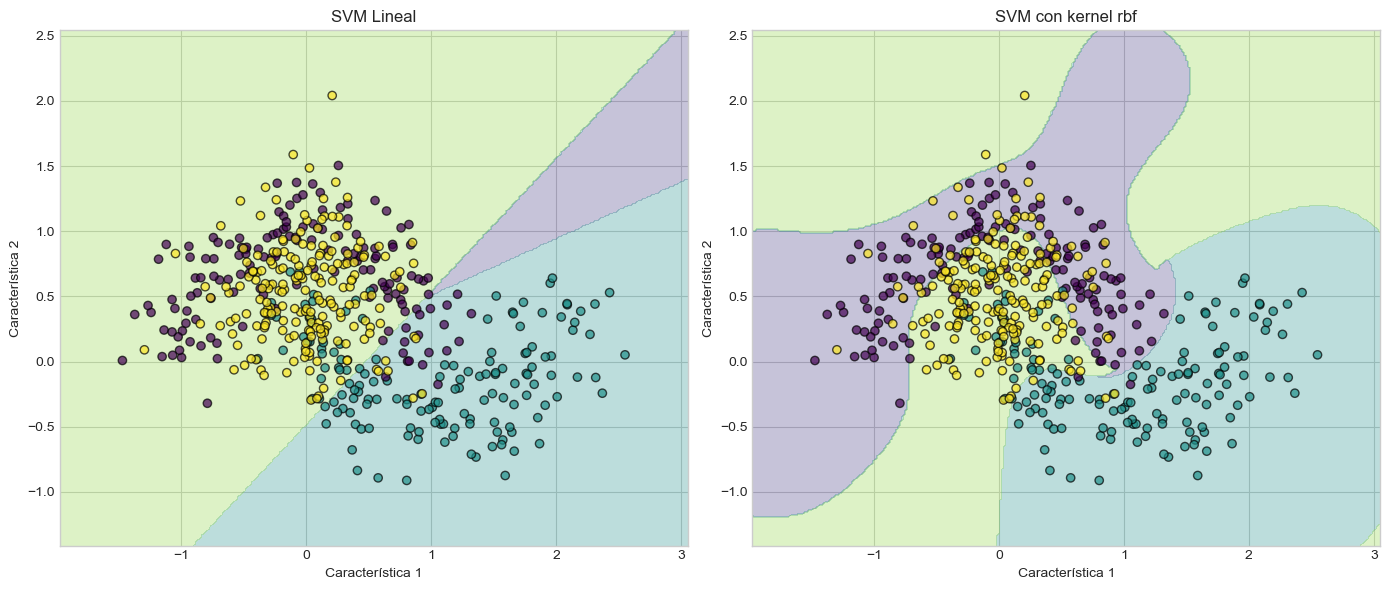

Comparación de rendimiento:
SVM lineal:
  Accuracy: 0.6333
  Mejor C: 0.1

SVM con kernel rbf:
  Accuracy: 0.7600
  Mejores parámetros: {'C': 100, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}


In [41]:
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundary(model, X, y, title, ax):
    # Creamos la malla de puntos
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    
    # Predecimos cada punto de la malla
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Dibujamos fronteras
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis', levels=np.arange(-0.5, 3, 1))
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('Característica 1')
    ax.set_ylabel('Característica 2')
    return scatter

# Creamos la figura con dos subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Frontera del modelo lineal
plot_decision_boundary(best_svm_linear, X, y, 'SVM Lineal', axes[0])

# Frontera del modelo no lineal
plot_decision_boundary(best_svm_nonlinear, X, y, f'SVM con kernel {best_svm_nonlinear.kernel}', axes[1])

plt.tight_layout()
plt.show()

# Comparación de métricas
print("Comparación de rendimiento:")
print(f"SVM lineal:")
print(f"  Accuracy: {acc_linear:.4f}")
print(f"  Mejor C: {grid_linear.best_params_['C']}")
print()
print(f"SVM con kernel {best_svm_nonlinear.kernel}:")
print(f"  Accuracy: {acc_nonlinear:.4f}")
print(f"  Mejores parámetros: {grid_nonlinear.best_params_}")

Hemos generado dos gráficas, una para el SVM lineal y otra para el SVM con kernel RBF. Como se puede observar, se usan técnicas diferentes en cada una.

- **SVM lineal:**
La frontera de decisión es una línea recta. No logra separar las dos lunas intercaladas, por lo que la clase 0 (luna izquierda) queda completamente oculta. La línea recta es insuficiente para un problema no lineal.

- **SVM con kernel RBF:**
La frontera de decisión es curva y mucho más flexible. El modelo logra rodear cada luna y separar la nube gaussiana central. Esto permite clasificar correctamente las tres clases.

El kernel no lineal mejora la precisión en un 12.67%, demostrando ser más adecuado para datasets con geometrías complejas.

## Ejercicio 5: Discusión y comparación de resultados

**Resumen de resultados**

| Modelo | Accuracy test | Mejores parámetros |
|--------|---------------|-------------------|
| SVM lineal | 63.33% | C = 0.1 |
| SVM con kernel RBF | 76.00% | C = 100, gamma = 'scale', kernel = 'rbf' |

El SVM lineal ha demostrado ser insuficiente para este problema. Su frontera de decisión lineal no puede separar las dos lunas intercaladas, lo que provoca que la clase 0 sea completamente ignorada por el clasificador (precision y recall = 0).

El SVM con kernel RBF, en cambio, ha logrado una mejora significativa del 12.67% en accuracy. Su frontera curva y flexible permite adaptarse a la geometría de los datos, separando correctamente las dos lunas y la nube gaussiana central.

**Conclusión**

Para problemas de clasificación con estructuras no lineales y solapamiento entre clases, el uso de kernels no lineales en SVM es fundamental. El kernel RBF, junto con un ajuste adecuado de hiperparámetros (C, gamma), consigue un rendimiento muy superior al del kernel lineal. La visualización de las fronteras de decisión confirma visualmente esta mejora.